# 01 — Exploratory Data Analysis

**Objective:** Load the Lending Club accepted loans dataset, understand its structure, explore distributions, identify data quality issues, and create the default target variable.

**Dataset:** `accepted_2007_to_2018Q4.csv` — **2,260,701 loans** across **151 features**, ~6.28 GB in memory

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Load the Dataset

In [ ]:
df = pd.read_csv('../data/accepted_2007_to_2018Q4.csv', low_memory=False)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Dataset shape: (2260701, 151)
Memory usage: 6.28 GB


In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,675.00,679.00,1.00,30.00,NaN,7.00,0.00,2765.00,29.70,13.00,w,0.00,0.00,...,178050.00,7746.00,2400.00,13734.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.00,Dec-1999,715.00,719.00,4.00,6.00,NaN,22.00,0.00,21470.00,19.20,38.00,w,0.00,0.00,...,314017.00,39475.00,79300.00,24667.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.00,Aug-2000,695.00,699.00,0.00,NaN,NaN,6.00,0.00,7869.00,56.20,18.00,w,0.00,0.00,...,218418.00,18696.00,6200.00,14877.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.00,35000.00,35000.00,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.00,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.00,Sep-2008,785.00,789.00,0.00,NaN,NaN,13.00,0.00,7802.00,11.60,17.00,w,15897.65,15897.65,...,381215.00,52226.00,62500.00,18000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.00,10400.00,10400.00,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.00,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.37,1.00,Jun-1998,695.00,699.00,3.00,12.00,NaN,12.00,0.00,21929.00,64.50,35.00,w,0.00,0.00,...,439570.00,95768.00,20300.00,88097.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.00,40000.00,40000.00,60 months,10.49,859.56,B,B3,Vice President,9 years,MORTGAGE,227000.00,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,907xx,CA,12.75,7.00,Feb-1995,705.00,709.00,1.00,9.00,NaN,5.00,0.00,8633.00,64.90,37.00,f,23252.59,23252.59,...,55970.00,28398.00,12300.00,42670.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.00,24000.00,24000.00,60 months,14.49,564.56,C,C4,Program Manager,6 years,RENT,110000.00,Not Verified,Oct-2016,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,334xx,FL,18.30,0.00,Jul-1999,660.00,664.00,0.00,67.00,72.00,10.00,1.00,17641.00,68.10,31.00,f,0.00,0.00,...,84664.00,62426.00,20700.00,58764.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.00,44.82,1.00
2260698,88215728,NaN,14000.00,14000.00,14000.00,60 months,14.49,329.33,C,C4,Customer Service Technician,10+ years,MORTGAGE,95000.00,Verified,Oct-2016,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,NaN,770xx,TX,23.36,0.00,Jun-1996,660.00,664.00,1.00,37.00,NaN,8.00,0.00,7662.00,54.00,22.00,w,8456.12,8456.12,...,163804.00,44215.00,9500.00,34169.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Dataset Overview

- **109 numeric** (`float64`) and **42 object/categorical** columns
- `member_id` is entirely null (deprecated field)
- 71.2% of loans are 36-month term; 28.8% are 60-month
- Grade B is the most common (663,557 loans), followed by C
- Most frequent sub-grade: C1 (145,903 loans)
- 95.3% Individual applications, 4.7% Joint App
- "Teacher" is the most common employer title (38,824)
- Debt consolidation dominates loan purpose (1,277,877 loans — 56.5%)
- California is the top state (314,533 loans — 13.9%)
- `desc` (loan description) is 94.4% null — rarely filled by borrowers

In [5]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  object 
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  object 
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  object 
 9    sub_grade                                   

In [6]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,...,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260664.00,2258957.00,2260639.00,2260668.00,2260668.00,2260638.00,1102166.00,359156.00,2260639.00,2260639.00,2260668.00,2258866.00,2260639.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260523.00,580775.00,2260668.00,120710.00,120706.00,2260639.00,2190392.00,2190392.00,1394538.00,...,2190392.00,2190392.00,2190392.00,2190391.00,2190392.00,2202078.00,2107011.00,2190392.00,2190392.00,2190392.00,2190237.00,2185289.00,2259303.00,2260563.00,2190392.00,2210638.00,2210638.00,2190392.00,108020.00,108021.00,108021.00,108021.00,108021.00,108021.00,106184.00,108021.00,108021.00,108021.00,108021.00,35942.00,10917.00,10917.00,10917.00,10917.00,8651.00,10917.00,10917.00,34246.00,34246.00,34246.00
mean,NaN,15046.93,15041.66,15023.44,13.09,445.81,77992.43,18.82,0.31,698.59,702.59,0.58,34.54,72.31,11.61,0.20,16658.46,50.34,24.16,4206.89,4205.97,12082.56,12064.39,9505.77,2431.39,1.52,143.88,23.98,3429.35,687.66,675.54,0.02,44.16,1.00,123624.64,19.25,0.00,232.73,142492.20,0.93,...,7.73,8.41,8.25,14.00,5.58,11.63,0.00,0.00,0.08,2.08,94.11,42.44,0.13,0.05,178242.75,51022.94,23193.77,43732.01,33617.28,669.76,673.76,0.63,1.54,11.47,58.17,3.01,12.53,0.05,0.08,36.94,3.00,155.05,3.00,13.74,454.80,11636.88,193.99,5010.66,47.78,13.19
std,NaN,9190.25,9188.41,9192.33,4.83,267.17,112696.20,14.18,0.87,33.01,33.01,0.89,21.90,26.46,5.64,0.57,22948.31,24.71,11.99,7343.24,7342.33,9901.38,9896.99,8321.85,2679.74,11.84,748.16,131.23,6018.25,72.97,111.10,0.15,21.53,0.00,74161.35,7.82,0.07,8518.46,160692.64,1.14,...,4.70,7.36,4.68,8.04,3.29,5.64,0.03,0.06,0.49,1.83,9.04,36.22,0.36,0.38,181574.81,49911.24,23006.56,45072.98,28153.87,44.73,44.73,0.99,1.76,6.63,25.55,3.28,8.15,0.41,0.41,23.92,0.00,129.04,0.00,9.67,375.39,7625.99,198.63,3693.12,7.31,8.16
min,NaN,500.00,500.00,0.00,5.31,4.93,0.00,-1.00,0.00,610.00,614.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,5693.51,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,540.00,544.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.64,3.00,0.00,1.92,55.73,0.01,44.21,0.20,0.00
25%,NaN,8000.00,8000.00,8000.00,9.49,251.65,46000.00,11.89,0.00,675.00,679.00,0.00,16.00,55.00,8.00,0.00,5950.00,31.50,15.00,0.00,0.00,4546.46,4531.80,3000.00,728.19,0.00,0.00,0.00,310.33,654.00,650.00,0.00,27.00,1.00,83400.00,13.53,0.00,0.00,29092.00,0.00,...,4.00,3.00,5.00,8.00,3.00,8.00,0.00,0.00,0.00,1.00,91

In [7]:
df.describe(include='object')

,id,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,next_pymnt_d,last_credit_pull_d,application_type,verification_status_joint,sec_app_earliest_cr_line,hardship_flag,hardship_type,hardship_reason,hardship_status,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_loan_status,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date
count,2260701,2260668,2260668,2260668,2093699,2113761,2260668,2260668,2260668,2260668,2260668,2260668,126065,2260668,2237342,2260667,2260668,2260639,2260668,2258241,915358,2260596,2260668,115730,108021,2260668,10917,10917,10917,10917,10917,10917,10917,2260668,2260668,34246,34246,34246
unique,2260701,2,7,35,512694,11,6,3,139,9,2,2260668,124500,14,63154,956,51,754,2,136,106,141,2,3,663,2,1,9,3,27,28,27,5,2,2,83,3,90
top,Total amount funded in policy code 2: 521953170,36 months,B,C1,Teacher,10+ years,MORTGAGE,Source Verified,Mar-2016,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,,debt_consolidation,Debt consolidation,112xx,CA,Sep-2004,w,Mar-2019,Apr-2019,Mar-2019,Individual,Not Verified,Aug-2006,N,INTEREST ONLY-3 MONTHS DEFERRAL,NATURAL_DISASTER,COMPLETED,Sep-2017,Dec-2017,Sep-2017,Late (16-30 days),Cash,N,Feb-2019,ACTIVE,Jan-2019
freq,1,1609754,663557,145903,38824,748005,1111450,886231,61992,1076751,2260048,1,252,1277877,1153293,23908,314533,15400,1535467,853003,912221,1371381,2139958,57403,998,2259836,10917,2965,7819,2444,1756,1715,4770,2182546,2226422,2606,14704,1710


## 3. Missing Values Analysis

150 out of 151 columns have at least some missing values — only **1 column** has zero nulls.

| Threshold | Column Count |
|-----------|-------------|
| >80% missing | 39 columns |
| >50% missing | 44 columns |
| 0% missing | 1 column |

The 44 columns with >50% missing fall into three groups:
- **Joint application fields** (`sec_app_*`, `annual_inc_joint`, `dti_joint`, `verification_status_joint`, `revol_bal_joint`) — missing for the ~95% of loans that are Individual applications
- **Hardship/settlement fields** — post-default program data, only populated for ~10,900 hardship cases and ~34,200 settlements
- **Delinquency history fields** (`mths_since_last_delinq` at 51.6%, `mths_since_last_record`, `mths_since_last_major_derog`, etc.) — missing means "no delinquency event", which is informative and will need careful handling

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

missing_df[missing_df['missing_pct'] > 0]

,missing_count,missing_pct
member_id,2260701,100.00
orig_projected_additional_accrued_interest,2252050,99.62
hardship_reason,2249784,99.52
hardship_payoff_balance_amount,2249784,99.52
hardship_last_payment_amount,2249784,99.52
...,...,...
total_rec_late_fee,33,0.00
total_rec_int,33,0.00
disbursement_method,33,0.00
hardship_flag,33,0.00


In [9]:
high_missing = missing_df[missing_df['missing_pct'] > 50]
print(f"Columns with >50% missing: {len(high_missing)}")
print(f"Columns with >80% missing: {len(missing_df[missing_df['missing_pct'] > 80])}")
print(f"Columns with 0% missing: {len(missing_df[missing_df['missing_pct'] == 0])}")
print(f"\nColumns to consider dropping (>50% missing):")
print(high_missing.index.tolist())

Columns with >50% missing: 44
Columns with >80% missing: 39
Columns with 0% missing: 1

Columns to consider dropping (>50% missing):
['member_id', 'orig_projected_additional_accrued_interest', 'hardship_reason', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'payment_plan_start_date', 'hardship_type', 'hardship_status', 'hardship_start_date', 'deferral_term', 'hardship_amount', 'hardship_dpd', 'hardship_loan_status', 'hardship_length', 'hardship_end_date', 'settlement_status', 'debt_settlement_flag_date', 'settlement_term', 'settlement_percentage', 'settlement_date', 'settlement_amount', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_inq_last_6mths', 'sec_app_num_rev_accts', 'sec_app_open_acc', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_mort_acc', 'sec_app_open_act_il', 'sec_app_fico_range_low', 'sec_app_collections_12_mths_ex_med', 'sec_app_chargeoff_within_12_mths', 'verification_status_joint', 'dti_joi

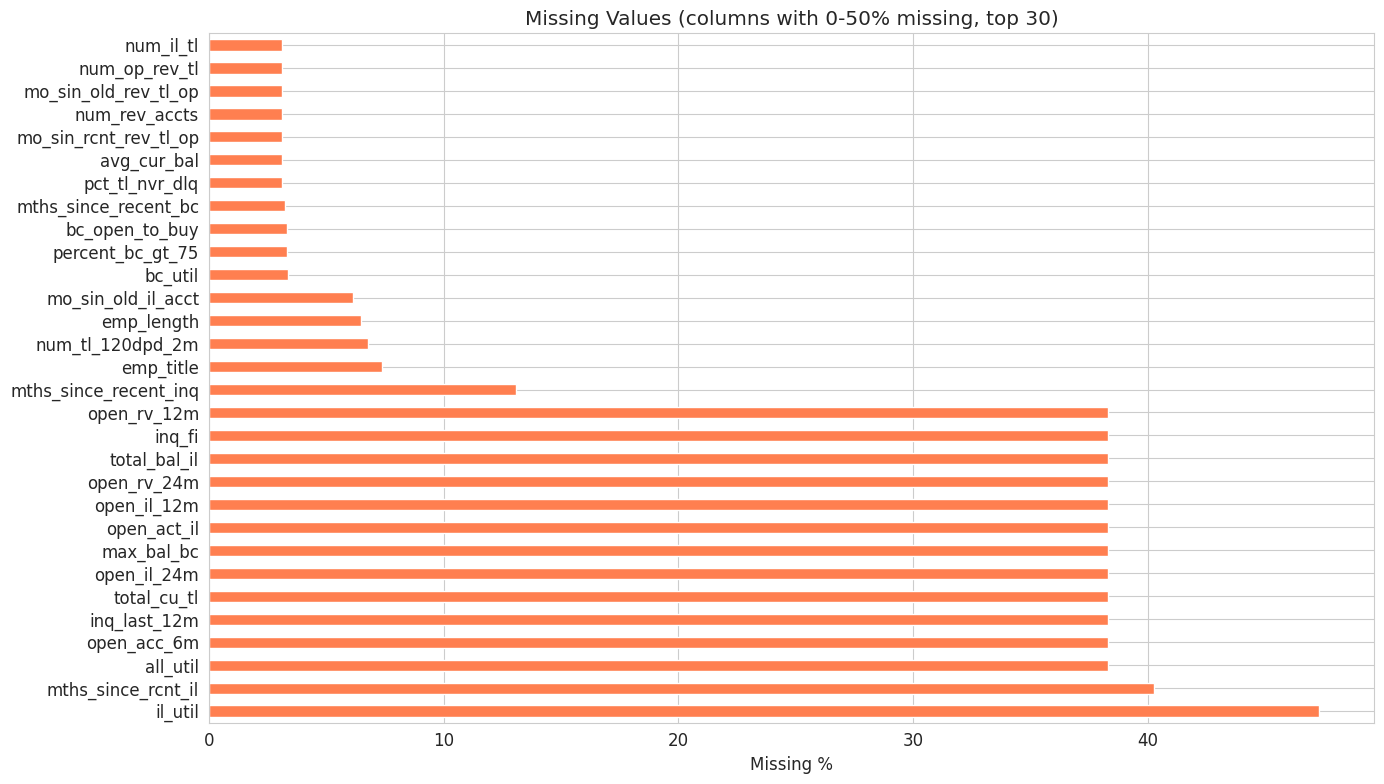

In [10]:
fig, ax = plt.subplots(figsize=(14, 8))
cols_with_missing = missing_df[(missing_df['missing_pct'] > 0) & (missing_df['missing_pct'] <= 50)]
if len(cols_with_missing) > 30:
    cols_with_missing = cols_with_missing.head(30)

cols_with_missing['missing_pct'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values (columns with 0-50% missing, top 30)')
plt.tight_layout()
plt.show()

## 4. Target Variable: Loan Status

9 unique loan statuses. The two dominant outcomes are **Fully Paid (47.6%)** and **Current (38.9%)**. "Charged Off" at 11.9% is the primary default category. Only 40 loans carry the explicit "Default" status.

| Status | Count | % |
|--------|------:|--:|
| Fully Paid | 1,076,751 | 47.63% |
| Current | 878,317 | 38.85% |
| Charged Off | 268,559 | 11.88% |
| Late (31-120 days) | 21,467 | 0.95% |
| In Grace Period | 8,436 | 0.37% |
| Late (16-30 days) | 4,349 | 0.19% |
| DMCP: Fully Paid | 1,988 | 0.09% |
| DMCP: Charged Off | 761 | 0.03% |
| Default | 40 | <0.01% |

"Current" (38.9%) and all late-stage loans are **excluded** from modeling since their final outcome is unknown — this removes 912,569 loans.

In [11]:
print("Loan status distribution:")
status_counts = df['loan_status'].value_counts()
status_pct = df['loan_status'].value_counts(normalize=True) * 100
pd.DataFrame({'count': status_counts, 'pct': status_pct})

Loan status distribution:


,count,pct
loan_status,,
Fully Paid,1076751,47.63
Current,878317,38.85
Charged Off,268559,11.88
Late (31-120 days),21467,0.95
In Grace Period,8436,0.37
Late (16-30 days),4349,0.19
Does not meet the credit policy. Status:Fully Paid,1988,0.09
Does not meet the credit policy. Status:Charged Off,761,0.03
Default,40,0.00


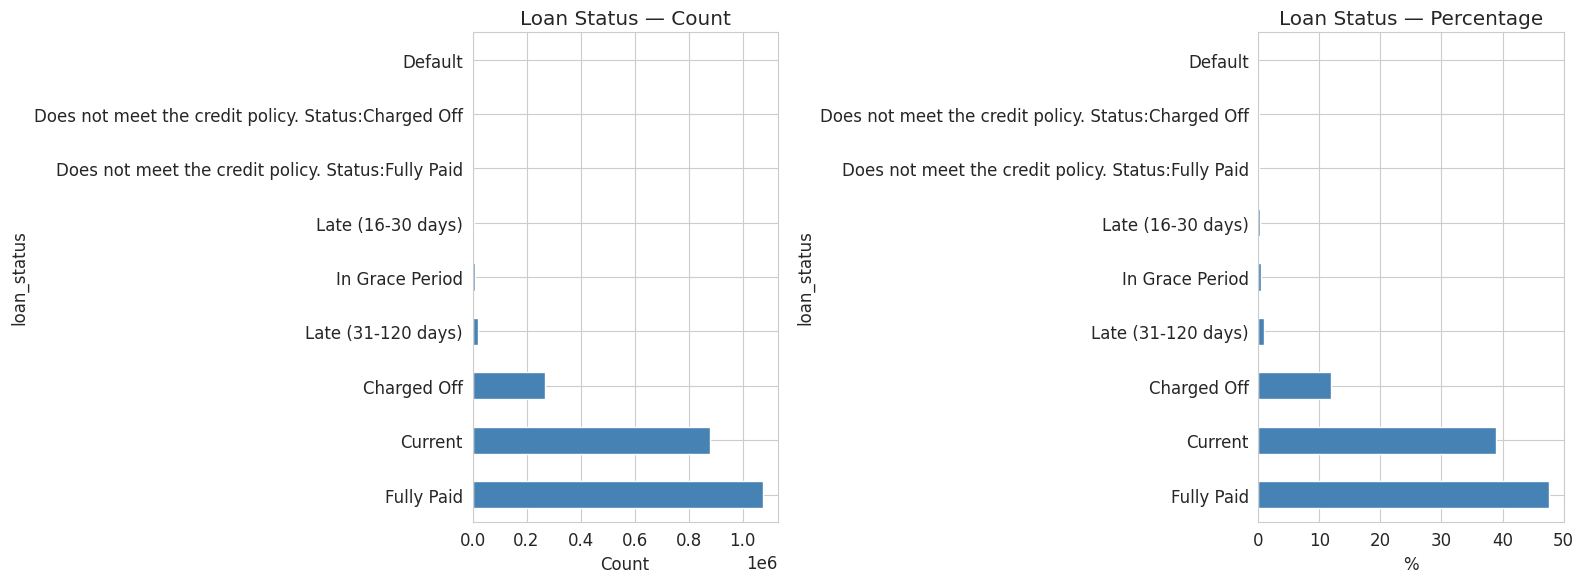

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Loan Status — Count')
axes[0].set_xlabel('Count')

status_pct.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Loan Status — Percentage')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

### Create Binary Default Target

After filtering to resolved loans only:
- **Modeling dataset:** 1,348,099 loans (excluded 912,569 ongoing/late)
- **Default rate:** 19.98% (269,360 defaults vs 1,078,739 non-defaults)
- **Class imbalance:** ~1:4 ratio (default : non-default) — moderate imbalance, manageable without aggressive resampling

Default definition:
- **1 (Default):** Charged Off (268,559) + Default (40) + DMCP: Charged Off (761)
- **0 (Non-default):** Fully Paid (1,076,751) + DMCP: Fully Paid (1,988)
- **Excluded:** Current, In Grace Period, Late (16-30 days), Late (31-120 days)

In [13]:
default_statuses = ['Charged Off', 'Default', 
                    'Does not meet the credit policy. Status:Charged Off']
non_default_statuses = ['Fully Paid', 
                        'Does not meet the credit policy. Status:Fully Paid']

exclude_statuses = ['Current', 'In Grace Period', 
                    'Late (16-30 days)', 'Late (31-120 days)', 'Issued']

df_model = df[df['loan_status'].isin(default_statuses + non_default_statuses)].copy()
df_model['default'] = df_model['loan_status'].isin(default_statuses).astype(int)

print(f"Original dataset: {len(df):,} loans")
print(f"Excluded (ongoing/late): {len(df[df['loan_status'].isin(exclude_statuses)]):,} loans")
print(f"Modeling dataset: {len(df_model):,} loans")
print(f"\nDefault rate: {df_model['default'].mean():.4f} ({df_model['default'].mean()*100:.2f}%)")
print(f"Defaults: {df_model['default'].sum():,}")
print(f"Non-defaults: {(df_model['default'] == 0).sum():,}")

Original dataset: 2,260,701 loans
Excluded (ongoing/late): 912,569 loans
Modeling dataset: 1,348,099 loans

Default rate: 0.1998 (19.98%)
Defaults: 269,360
Non-defaults: 1,078,739


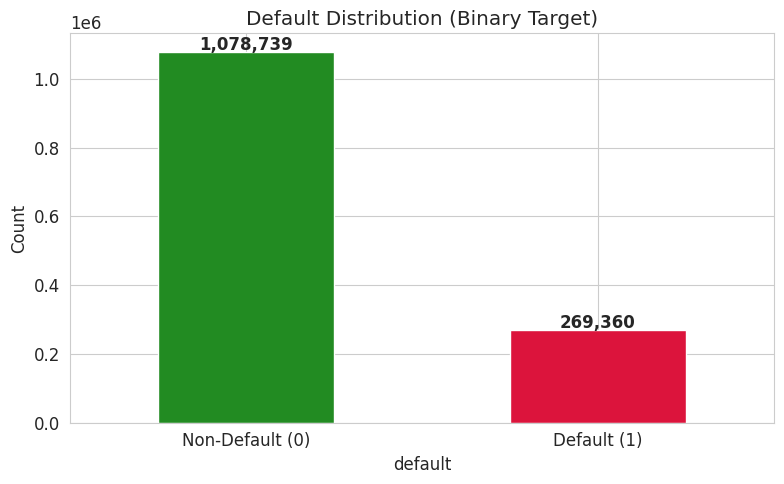

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
df_model['default'].value_counts().plot(kind='bar', ax=ax, 
                                         color=['forestgreen', 'crimson'])
ax.set_title('Default Distribution (Binary Target)')
ax.set_xticklabels(['Non-Default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Count')
for i, v in enumerate(df_model['default'].value_counts().values):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Categorization

151 features grouped into four categories. The 98 "Other" features include detailed credit bureau fields (tradeline counts, balances, utilization breakdowns), joint application data, and hardship/settlement fields.

| Category | Count | Examples |
|----------|------:|---------|
| Loan info | 11 | `loan_amnt`, `int_rate`, `grade`, `term` |
| Borrower | 10 | `annual_inc`, `emp_length`, `home_ownership`, `dti` |
| Credit history | 17 | `fico_range_*`, `delinq_2yrs`, `revol_util`, `open_acc` |
| Payment/performance | 15 | `total_pymnt`, `recoveries`, `last_pymnt_d` (leakage) |
| Other | 98 | Detailed tradeline, joint app, hardship fields |

In [15]:
loan_info_cols = ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
                  'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'issue_d']

borrower_cols = ['emp_title', 'emp_length', 'home_ownership', 'annual_inc',
                 'verification_status', 'purpose', 'title', 'zip_code', 
                 'addr_state', 'dti']

credit_history_cols = ['delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 
                       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
                       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
                       'revol_util', 'total_acc', 'collections_12_mths_ex_med',
                       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
                       'total_rev_hi_lim']

payment_cols = ['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
                'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
                'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
                'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
                'last_fico_range_high', 'last_fico_range_low']

print(f"Loan info features: {len(loan_info_cols)}")
print(f"Borrower features: {len(borrower_cols)}")
print(f"Credit history features: {len(credit_history_cols)}")
print(f"Payment/performance features: {len(payment_cols)}")
print(f"Other features: {len(df.columns) - len(loan_info_cols) - len(borrower_cols) - len(credit_history_cols) - len(payment_cols)}")

Loan info features: 11
Borrower features: 10
Credit history features: 17
Payment/performance features: 15
Other features: 98


## 6. Loan Characteristics Analysis

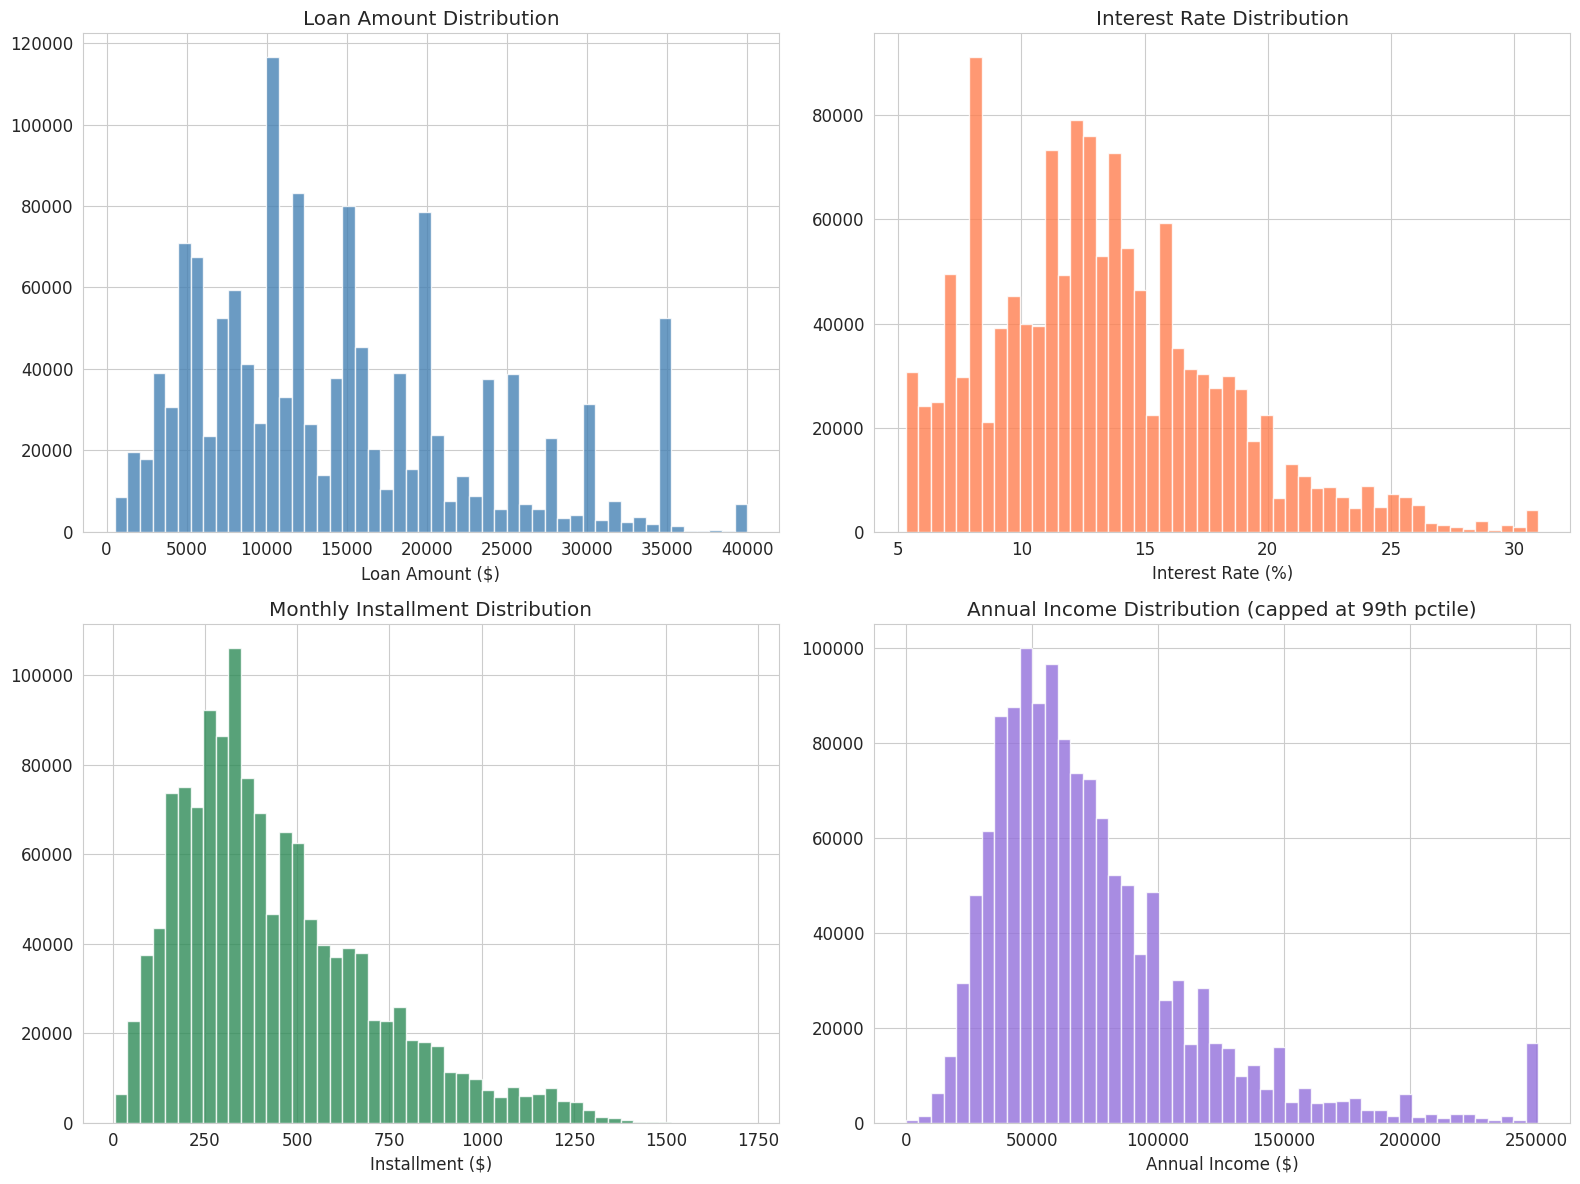

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loan amount
axes[0, 0].hist(df_model['loan_amnt'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Loan Amount Distribution')
axes[0, 0].set_xlabel('Loan Amount ($)')

# Interest rate
int_rate = df_model['int_rate'].astype(str).str.rstrip('%').astype(float) if df_model['int_rate'].dtype == 'object' else df_model['int_rate']
axes[0, 1].hist(int_rate.dropna(), bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0, 1].set_title('Interest Rate Distribution')
axes[0, 1].set_xlabel('Interest Rate (%)')

# Installment
axes[1, 0].hist(df_model['installment'], bins=50, color='seagreen', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Monthly Installment Distribution')
axes[1, 0].set_xlabel('Installment ($)')

# Annual income (capped for visualization)
inc_cap = df_model['annual_inc'].clip(upper=df_model['annual_inc'].quantile(0.99))
axes[1, 1].hist(inc_cap.dropna(), bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Annual Income Distribution (capped at 99th pctile)')
axes[1, 1].set_xlabel('Annual Income ($)')

plt.tight_layout()
plt.show()

## 7. Default Rate by Key Features

Analyzing how default rate varies across categorical segments to identify the strongest risk drivers.

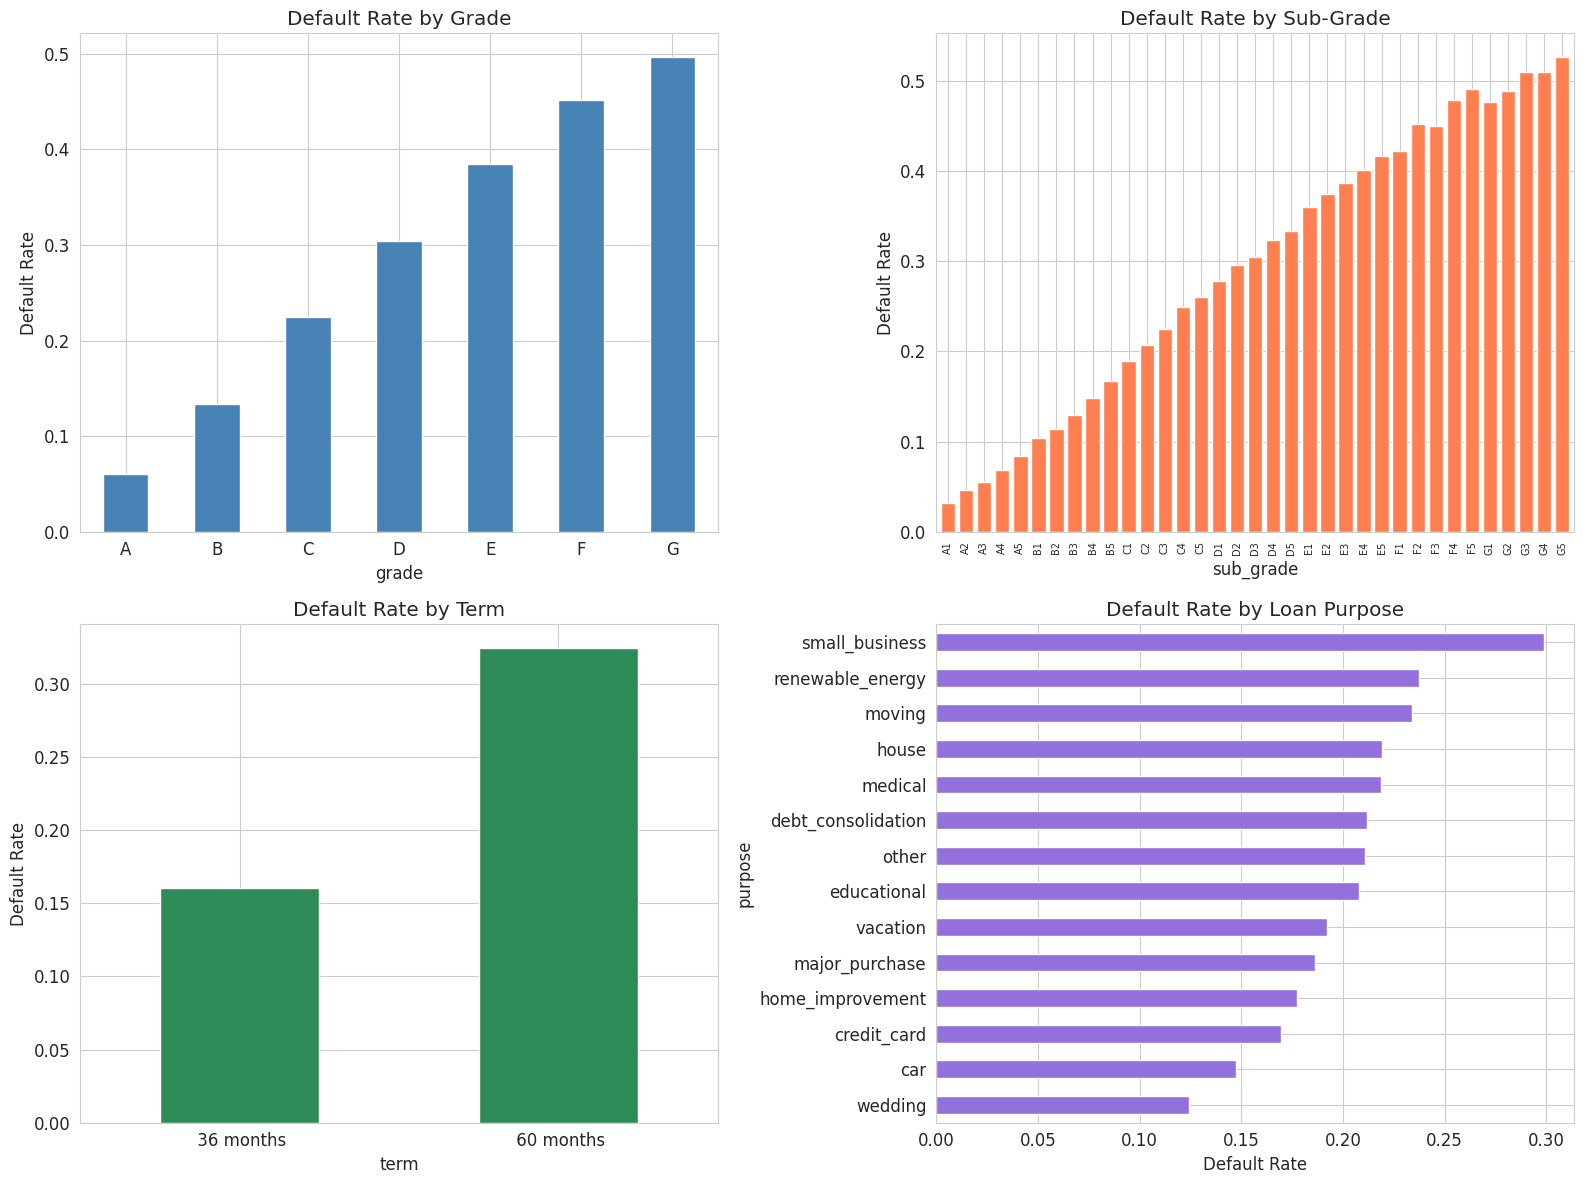

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Default rate by grade
grade_default = df_model.groupby('grade')['default'].mean().sort_index()
grade_default.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Default Rate by Grade')
axes[0, 0].set_ylabel('Default Rate')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# Default rate by sub-grade
subgrade_default = df_model.groupby('sub_grade')['default'].mean().sort_index()
subgrade_default.plot(kind='bar', ax=axes[0, 1], color='coral', width=0.8)
axes[0, 1].set_title('Default Rate by Sub-Grade')
axes[0, 1].set_ylabel('Default Rate')
axes[0, 1].tick_params(axis='x', labelsize=7)

# Default rate by term
term_default = df_model.groupby('term')['default'].agg(['mean', 'count'])
term_default['mean'].plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Default Rate by Term')
axes[1, 0].set_ylabel('Default Rate')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# Default rate by purpose
purpose_default = df_model.groupby('purpose')['default'].mean().sort_values(ascending=True)
purpose_default.plot(kind='barh', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Default Rate by Loan Purpose')
axes[1, 1].set_xlabel('Default Rate')

plt.tight_layout()
plt.show()

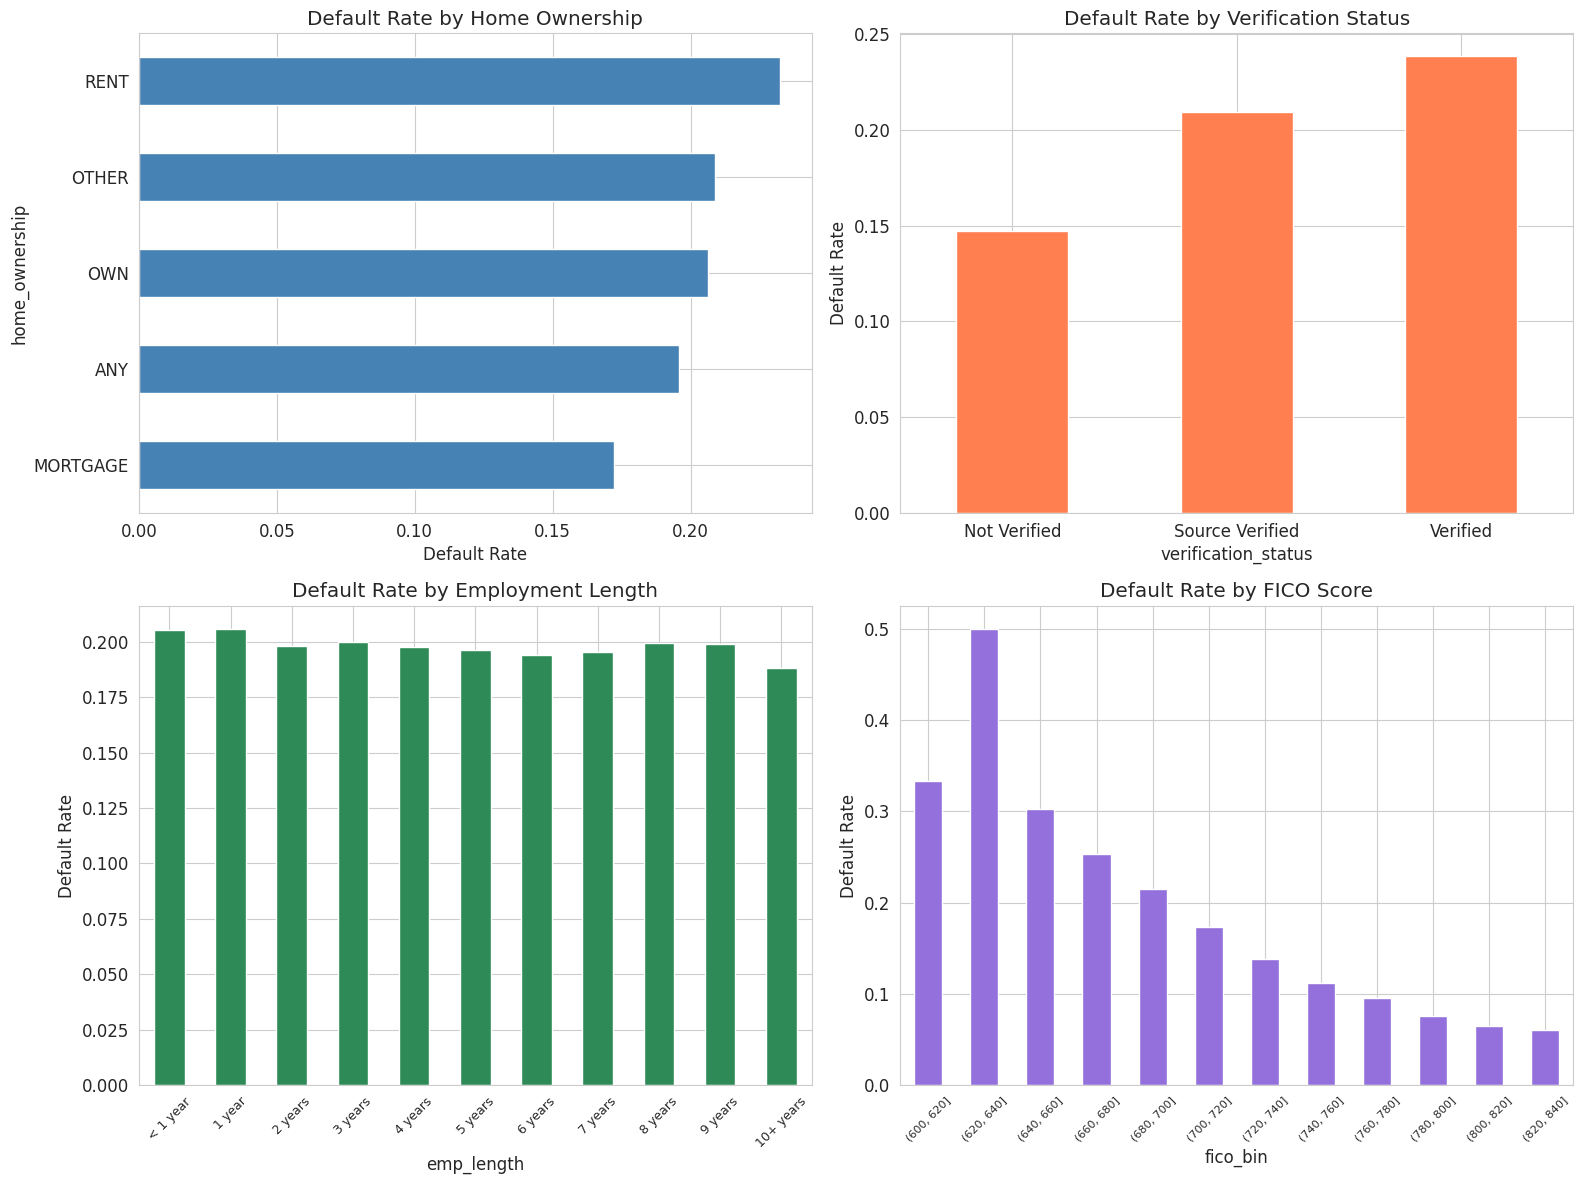

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Default rate by home ownership
home_default = df_model.groupby('home_ownership')['default'].agg(['mean', 'count'])
home_default = home_default[home_default['count'] > 100]
home_default['mean'].sort_values().plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Default Rate by Home Ownership')
axes[0, 0].set_xlabel('Default Rate')

# Default rate by verification status
verif_default = df_model.groupby('verification_status')['default'].mean()
verif_default.plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Default Rate by Verification Status')
axes[0, 1].set_ylabel('Default Rate')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Default rate by employment length
emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
             '6 years', '7 years', '8 years', '9 years', '10+ years']
emp_default = df_model.groupby('emp_length')['default'].mean()
emp_default = emp_default.reindex(emp_order)
emp_default.plot(kind='bar', ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Default Rate by Employment Length')
axes[1, 0].set_ylabel('Default Rate')
axes[1, 0].tick_params(axis='x', labelsize=9, rotation=45)

# Default rate by FICO score bins
df_model['fico_avg'] = (df_model['fico_range_low'] + df_model['fico_range_high']) / 2
df_model['fico_bin'] = pd.cut(df_model['fico_avg'], bins=range(600, 860, 20))
fico_default = df_model.groupby('fico_bin', observed=True)['default'].mean()
fico_default.plot(kind='bar', ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Default Rate by FICO Score')
axes[1, 1].set_ylabel('Default Rate')
axes[1, 1].tick_params(axis='x', labelsize=8, rotation=45)

plt.tight_layout()
plt.show()

## 8. Temporal Analysis — Default Rate Over Time

Loan issuance grew dramatically from 2007 to a peak around 2015, then declined. Default rates show clear vintage effects:

| Year | Loans | Default Rate | Avg Loan ($) | Avg Income ($) | Avg FICO |
|------|------:|:------------:|:------------:|:--------------:|:--------:|
| 2007 | 603 | 26% | 8,255 | 64,742 | 692 |
| 2009 | 5,281 | 14% | 9,833 | 69,192 | 717 |
| 2012 | 53,367 | 16% | 13,462 | 69,720 | 703 |
| 2015 | 375,546 | 20% | 14,642 | 76,269 | 696 |
| 2016 | 293,105 | 23% | 14,467 | 78,777 | 697 |
| 2017 | 169,321 | 23% | 14,301 | 78,953 | 701 |
| 2018 | 56,318 | 16% | 14,881 | 80,071 | 710 |

**Key observations:**
- 2007 vintage had the highest default rate (26%) — crisis-era originations
- 2009-2011 had the lowest defaults (14-15%) — post-crisis tightened underwriting
- Default rates climbed steadily from 2012 (16%) to 2016-2017 (23%) as lending standards loosened
- 2018 appears lower (16%) but this is misleading — these are younger vintages where many loans haven't had time to default yet (right-censoring)
- Average loan amount grew from ~$8K (2007) to ~$15K (2018); income and FICO trends are relatively stable

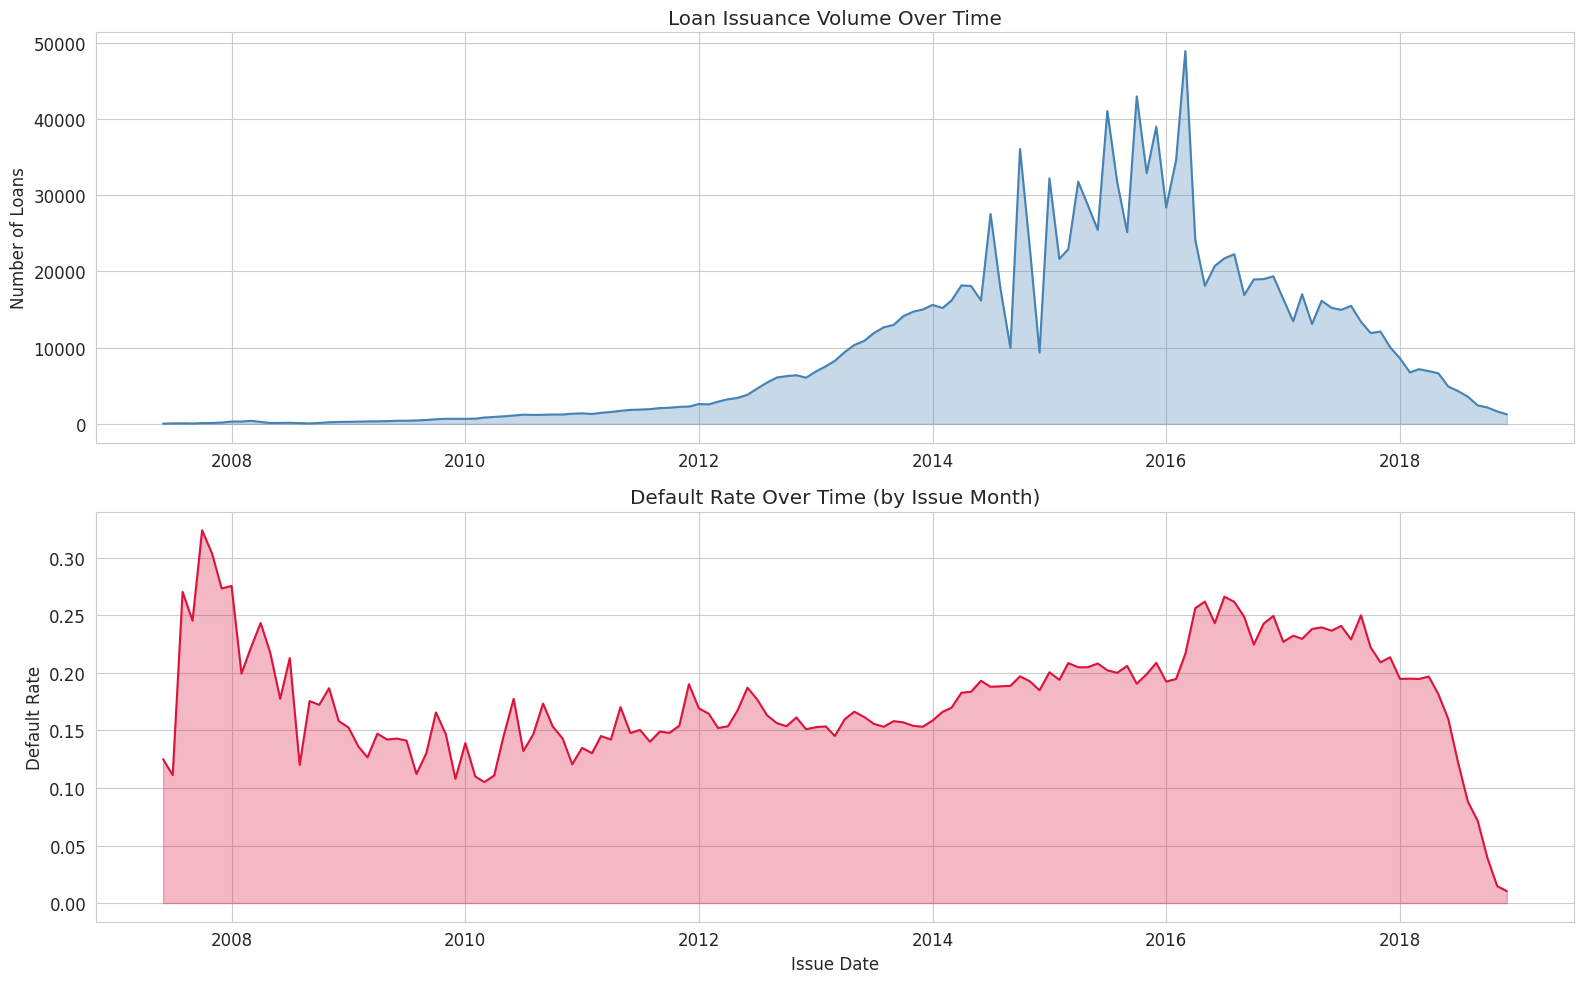

In [19]:
df_model['issue_date'] = pd.to_datetime(df_model['issue_d'], format='%b-%Y')
df_model['issue_year'] = df_model['issue_date'].dt.year
df_model['issue_month'] = df_model['issue_date'].dt.to_period('M')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Loan volume over time
monthly_volume = df_model.groupby('issue_month').size()
monthly_volume.index = monthly_volume.index.to_timestamp()
axes[0].plot(monthly_volume.index, monthly_volume.values, color='steelblue', linewidth=1.5)
axes[0].fill_between(monthly_volume.index, monthly_volume.values, alpha=0.3, color='steelblue')
axes[0].set_title('Loan Issuance Volume Over Time')
axes[0].set_ylabel('Number of Loans')

# Default rate over time
monthly_default = df_model.groupby('issue_month')['default'].mean()
monthly_default.index = monthly_default.index.to_timestamp()
axes[1].plot(monthly_default.index, monthly_default.values, color='crimson', linewidth=1.5)
axes[1].fill_between(monthly_default.index, monthly_default.values, alpha=0.3, color='crimson')
axes[1].set_title('Default Rate Over Time (by Issue Month)')
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('Issue Date')

plt.tight_layout()
plt.show()

In [20]:
yearly_stats = df_model.groupby('issue_year').agg(
    loan_count=('default', 'count'),
    default_rate=('default', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_annual_inc=('annual_inc', 'mean'),
    avg_fico=('fico_avg', 'mean')
).round(4)
yearly_stats

,loan_count,default_rate,avg_loan_amnt,avg_annual_inc,avg_fico
issue_year,,,,,
2007,603,0.26,8254.52,64742.25,691.97
2008,2393,0.21,8825.43,65241.74,699.10
2009,5281,0.14,9833.03,69192.29,716.97
2010,12537,0.14,10528.24,69512.99,715.04
2011,21721,0.15,12047.50,69456.01,716.99
2012,53367,0.16,13461.71,69720.23,703.39
2013,134804,0.16,14707.38,73226.92,697.00
2014,223103,0.18,14582.90,74552.36,694.47
2015,375546,0.20,14641.62,76269.29,695.52


## 9. Correlation Analysis (Numerical Features)

Pearson correlation of key numeric features with the `default` target:

| Feature | Correlation | Direction |
|---------|:-----------:|:---------:|
| `int_rate` | **0.26** | Higher rate = more default |
| `fico_avg` | **-0.13** | Higher FICO = less default |
| `dti` | 0.08 | Higher DTI = more default |
| `tot_cur_bal` | -0.07 | Higher balance = less default |
| `inq_last_6mths` | 0.07 | More inquiries = more default |
| `loan_amnt` | 0.07 | Larger loans = slightly more default |
| `revol_util` | 0.06 | Higher utilization = more default |
| `annual_inc` | -0.04 | Higher income = less default |

**Takeaway:** Interest rate is the strongest linear predictor (r=0.26), followed by FICO score (r=-0.13). Most correlations are weak individually, suggesting non-linear models and feature interactions will be important. High multicollinearity exists between `loan_amnt`/`funded_amnt`/`installment` and between `fico_range_low`/`fico_range_high` — these will need handling.

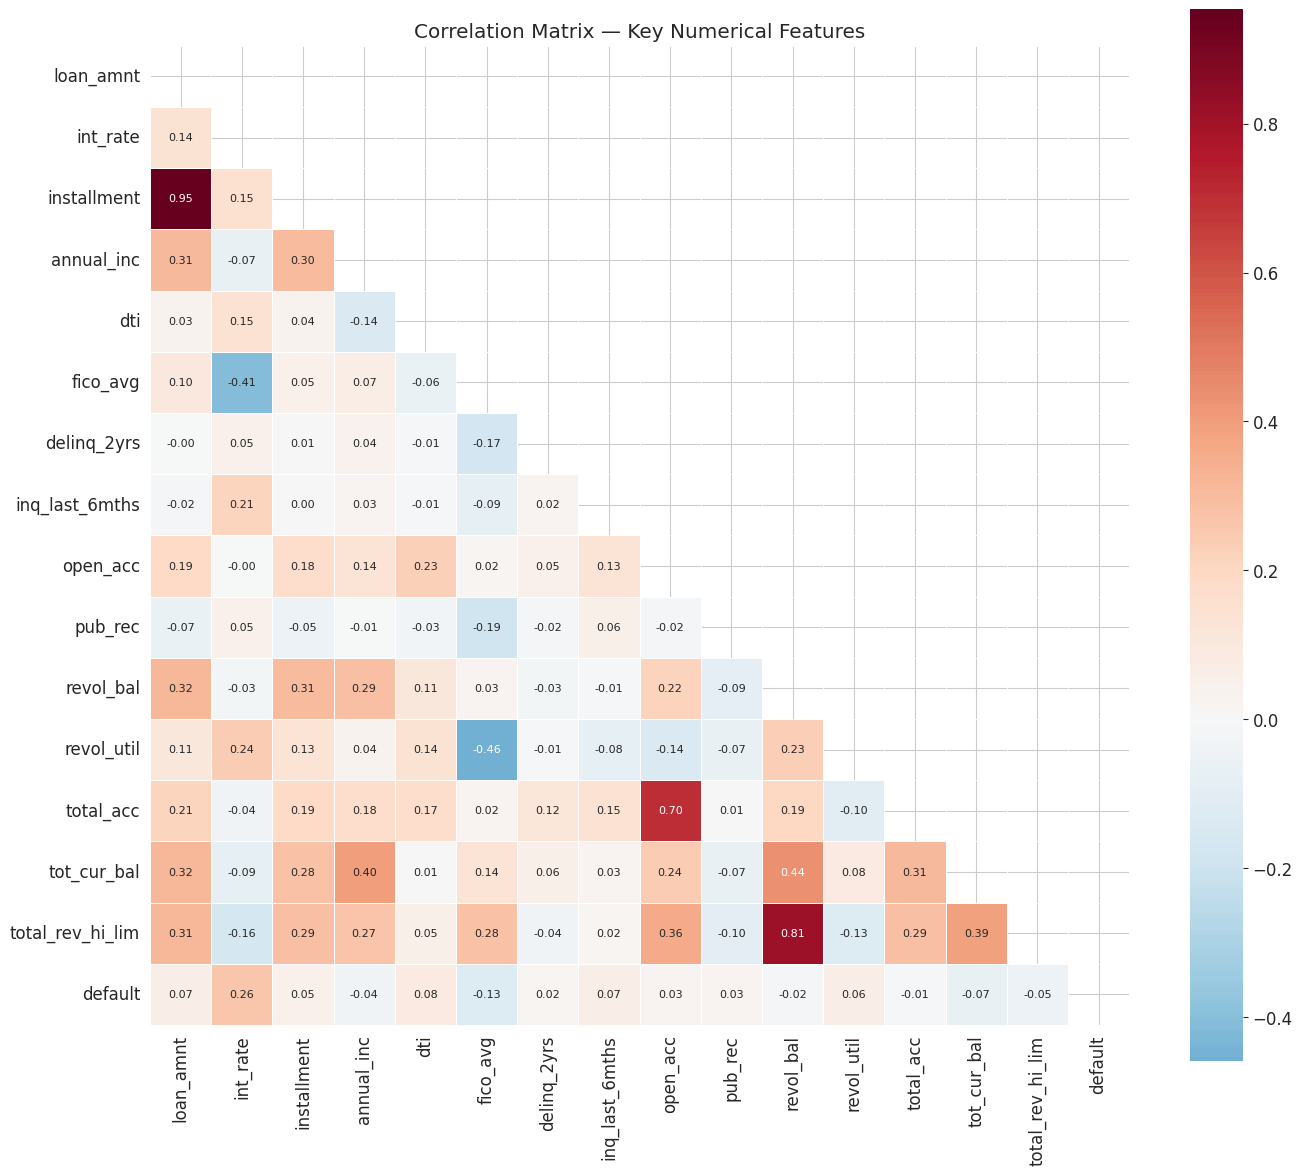

In [21]:
key_numeric_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
                    'fico_avg', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
                    'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
                    'tot_cur_bal', 'total_rev_hi_lim', 'default']

# int_rate may be string with %, handle it
if df_model['int_rate'].dtype == 'object':
    df_model['int_rate'] = df_model['int_rate'].astype(str).str.rstrip('%').astype(float)

corr_matrix = df_model[key_numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Numerical Features')
plt.tight_layout()
plt.show()

In [22]:
default_corr = corr_matrix['default'].drop('default').sort_values(key=abs, ascending=False)
print("Correlation with default target:")
print(default_corr.to_string())

Correlation with default target:
int_rate            0.26
fico_avg           -0.13
dti                 0.08
tot_cur_bal        -0.07
inq_last_6mths      0.07
loan_amnt           0.07
revol_util          0.06
total_rev_hi_lim   -0.05
installment         0.05
annual_inc         -0.04
open_acc            0.03
pub_rec             0.03
revol_bal          -0.02
delinq_2yrs         0.02
total_acc          -0.01


## 10. Numerical Feature Distributions: Default vs Non-Default

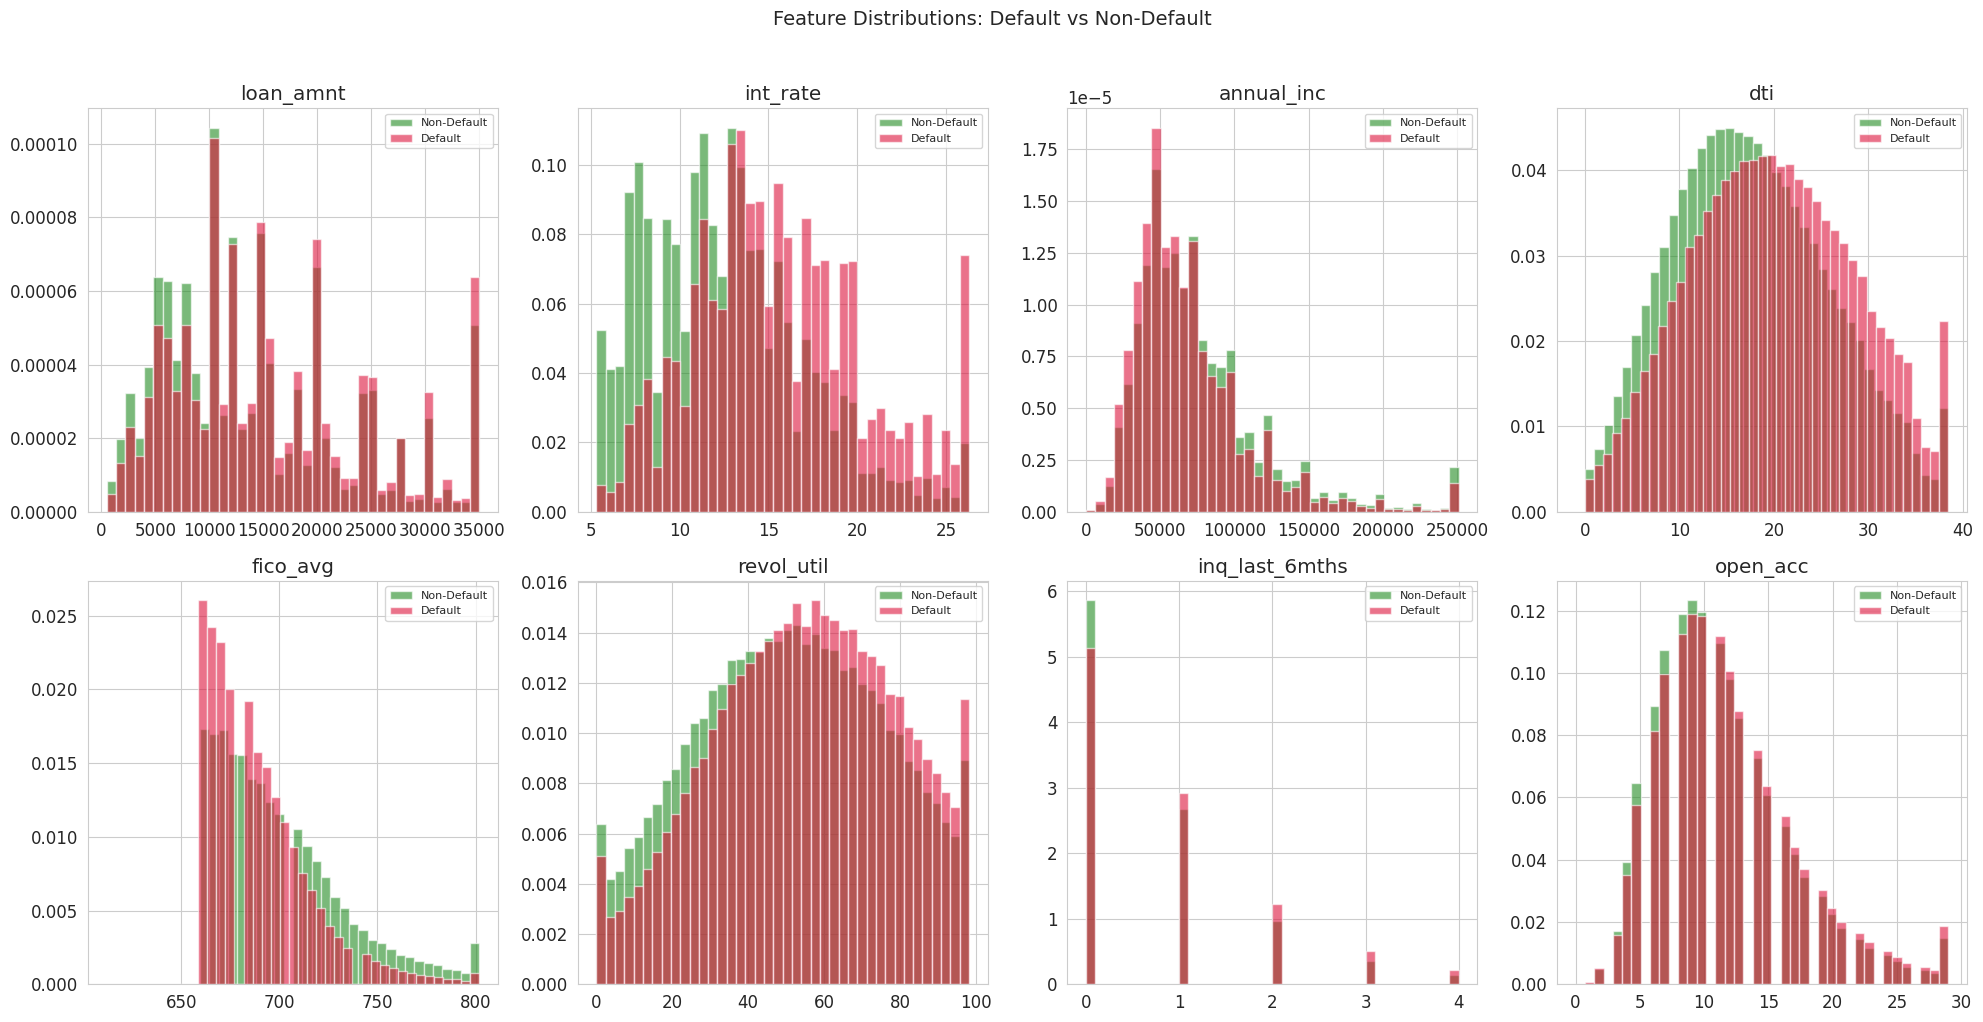

In [23]:
compare_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_avg',
                'revol_util', 'inq_last_6mths', 'open_acc']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(compare_cols):
    data_0 = df_model.loc[df_model['default'] == 0, col].dropna()
    data_1 = df_model.loc[df_model['default'] == 1, col].dropna()
    
    # Cap at 99th percentile for visualization
    upper = df_model[col].quantile(0.99)
    data_0 = data_0.clip(upper=upper)
    data_1 = data_1.clip(upper=upper)
    
    axes[i].hist(data_0, bins=40, alpha=0.6, color='forestgreen', 
                 label='Non-Default', density=True)
    axes[i].hist(data_1, bins=40, alpha=0.6, color='crimson', 
                 label='Default', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Default vs Non-Default', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. EAD & LGD Relevant Fields (Defaulted Loans Preview)

Previewing the target variables for EAD and LGD models using the **269,360 defaulted loans**.

- **Recovery Rate** = `recoveries / funded_amnt` — how much was recovered post-default
- **LGD** = `1 - recovery_rate` — fraction of exposure lost
- **EAD %** = `(funded_amnt - total_rec_prncp) / funded_amnt` — outstanding exposure at default as fraction of funded amount

In [24]:
df_defaulted = df_model[df_model['default'] == 1].copy()
print(f"Number of defaulted loans: {len(df_defaulted):,}")

# EAD proxy: outstanding principal at default
# For term loans, EAD ≈ funded_amnt (or out_prncp at time of default)
# LGD = 1 - recovery_rate
# recovery_rate = recoveries / funded_amnt (or total amount owed)

df_defaulted['recovery_rate'] = df_defaulted['recoveries'] / df_defaulted['funded_amnt']
df_defaulted['lgd'] = 1 - df_defaulted['recovery_rate']

# EAD as fraction of funded amount
df_defaulted['ead_pct'] = (df_defaulted['funded_amnt'] - df_defaulted['total_rec_prncp']) / df_defaulted['funded_amnt']

print(f"\nRecovery Rate stats:")
print(df_defaulted['recovery_rate'].describe())
print(f"\nLGD stats:")
print(df_defaulted['lgd'].describe())
print(f"\nEAD % (outstanding/funded) stats:")
print(df_defaulted['ead_pct'].describe())

Number of defaulted loans: 269,360

Recovery Rate stats:
count   269360.00
mean         0.08
std          0.10
min          0.00
25%          0.00
50%          0.06
75%          0.11
max          2.17
Name: recovery_rate, dtype: float64

LGD stats:
count   269360.00
mean         0.92
std          0.10
min         -1.17
25%          0.89
50%          0.94
75%          1.00
max          1.00
Name: lgd, dtype: float64

EAD % (outstanding/funded) stats:
count   269360.00
mean         0.70
std          0.22
min          0.00
25%          0.57
50%          0.75
75%          0.87
max          1.00
Name: ead_pct, dtype: float64


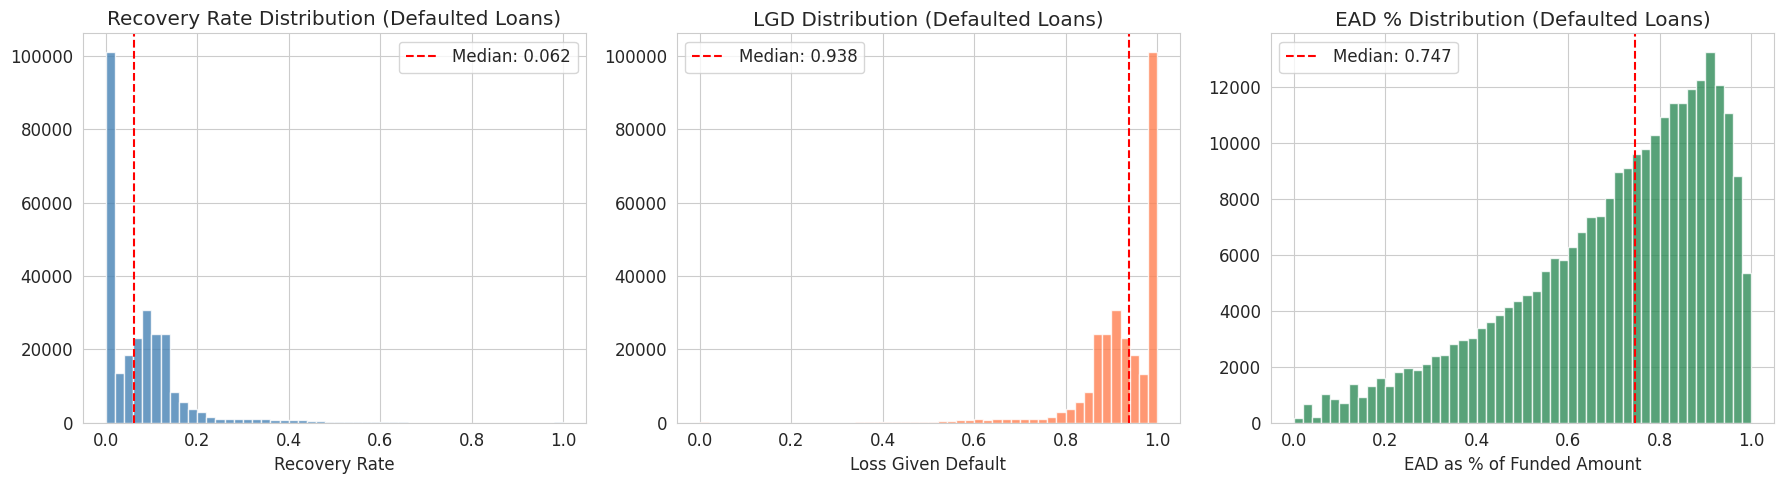

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_defaulted['recovery_rate'].clip(0, 1), bins=50, 
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Recovery Rate Distribution (Defaulted Loans)')
axes[0].set_xlabel('Recovery Rate')
axes[0].axvline(df_defaulted['recovery_rate'].median(), color='red', 
                linestyle='--', label=f"Median: {df_defaulted['recovery_rate'].median():.3f}")
axes[0].legend()

axes[1].hist(df_defaulted['lgd'].clip(0, 1), bins=50, 
             color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('LGD Distribution (Defaulted Loans)')
axes[1].set_xlabel('Loss Given Default')
axes[1].axvline(df_defaulted['lgd'].median(), color='red', 
                linestyle='--', label=f"Median: {df_defaulted['lgd'].median():.3f}")
axes[1].legend()

axes[2].hist(df_defaulted['ead_pct'].clip(0, 1), bins=50, 
             color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('EAD % Distribution (Defaulted Loans)')
axes[2].set_xlabel('EAD as % of Funded Amount')
axes[2].axvline(df_defaulted['ead_pct'].median(), color='red', 
                linestyle='--', label=f"Median: {df_defaulted['ead_pct'].median():.3f}")
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Data Quality Flags & Columns to Drop

**7 single-value columns** found (no predictive power): `member_id`, `pymnt_plan`, `policy_code`, `hardship_flag`, `hardship_type`, `deferral_term`, `hardship_length`

Columns flagged for removal:

| Category | Count | Reason |
|----------|------:|--------|
| Leakage (post-outcome) | 37 | Payment, recovery, settlement, hardship fields — known only after loan resolves |
| ID / text / URL | 7 | `id`, `member_id`, `url`, `desc`, `emp_title`, `title`, `zip_code` |
| Single-value | 7 | Constant across all rows — zero variance |
| Target-related | 2 | `loan_status`, `default` (target itself) |
| **Total to drop** | **48** | (some overlap between categories) |
| **Remaining features** | **109** | Available for modeling |

In [26]:
# Identify columns with single unique value
single_val_cols = [col for col in df_model.columns if df_model[col].nunique() <= 1]
print(f"Columns with <= 1 unique value: {single_val_cols}")

# Identify leakage columns — these are known AFTER the loan outcome
leakage_cols = ['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
                'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
                'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
                'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
                'last_fico_range_high', 'last_fico_range_low',
                'debt_settlement_flag', 'debt_settlement_flag_date',
                'settlement_status', 'settlement_date', 'settlement_amount',
                'settlement_percentage', 'settlement_term',
                'hardship_flag', 'hardship_type', 'hardship_reason',
                'hardship_status', 'deferral_term', 'hardship_amount',
                'hardship_start_date', 'hardship_end_date',
                'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
                'hardship_loan_status', 'orig_projected_additional_accrued_interest',
                'hardship_payoff_balance_amount', 'hardship_last_payment_amount']

# ID / URL / description columns — not predictive
id_cols = ['id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code']

# Target-related columns to exclude from features
target_cols = ['loan_status', 'default']

print(f"\nLeakage columns to remove: {len(leakage_cols)}")
print(f"ID/text columns to remove: {len(id_cols)}")
print(f"Single-value columns to remove: {len(single_val_cols)}")

Columns with <= 1 unique value: ['member_id', 'pymnt_plan', 'policy_code', 'hardship_flag', 'hardship_type', 'deferral_term', 'hardship_length']

Leakage columns to remove: 37
ID/text columns to remove: 7
Single-value columns to remove: 7


In [27]:
cols_to_drop = list(set(leakage_cols + id_cols + single_val_cols + target_cols))
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]

remaining_cols = [c for c in df_model.columns if c not in cols_to_drop]
print(f"Columns to drop: {len(cols_to_drop)}")
print(f"Remaining feature columns: {len(remaining_cols)}")
print(f"\nRemaining columns:")
for i, col in enumerate(sorted(remaining_cols)):
    print(f"  {i+1}. {col} ({df_model[col].dtype})")

Columns to drop: 48
Remaining feature columns: 109

Remaining columns:
  1. acc_now_delinq (float64)
  2. acc_open_past_24mths (float64)
  3. addr_state (object)
  4. all_util (float64)
  5. annual_inc (float64)
  6. annual_inc_joint (float64)
  7. application_type (object)
  8. avg_cur_bal (float64)
  9. bc_open_to_buy (float64)
  10. bc_util (float64)
  11. chargeoff_within_12_mths (float64)
  12. collections_12_mths_ex_med (float64)
  13. delinq_2yrs (float64)
  14. delinq_amnt (float64)
  15. disbursement_method (object)
  16. dti (float64)
  17. dti_joint (float64)
  18. earliest_cr_line (object)
  19. emp_length (object)
  20. fico_avg (float64)
  21. fico_bin (category)
  22. fico_range_high (float64)
  23. fico_range_low (float64)
  24. funded_amnt (float64)
  25. funded_amnt_inv (float64)
  26. grade (object)
  27. home_ownership (object)
  28. il_util (float64)
  29. initial_list_status (object)
  30. inq_fi (float64)
  31. inq_last_12m (float64)
  32. inq_last_6mths (float64

## 13. Key EDA Findings Summary

**Dataset:**
- 2,260,701 accepted loans from 2007-2018, 151 features, 6.28 GB in memory
- After filtering to resolved loans (Fully Paid + Charged Off/Default): **1,348,099 loans** for modeling
- 912,569 loans excluded (Current, Late, In Grace Period) due to unknown final outcome

**Target Variable:**
- Binary default: **19.98% default rate** (269,360 defaults vs 1,078,739 non-defaults)
- Moderate class imbalance (~1:4) — unlikely to need aggressive resampling

**Key Risk Drivers (from charts):**
- **Grade:** Default rate increases monotonically from A (~6%) to G (~35%+) — the single strongest categorical predictor
- **Interest rate:** Strongest numeric correlation with default (r=0.26) — directly reflects grade-based risk pricing
- **FICO score:** Second strongest predictor (r=-0.13) — higher FICO = lower default, as expected
- **Term:** 60-month loans default more than 36-month — longer exposure window + riskier borrowers
- **Purpose:** Small business loans have the highest default rate; credit card refinancing has the lowest
- **Employment length:** Relatively flat across categories — not a strong discriminator
- **Verification status:** Counter-intuitively, "Verified" and "Source Verified" have *higher* default rates than "Not Verified" — likely because riskier applicants trigger verification

**EAD & LGD Preview (269,360 defaulted loans):**
- **Recovery rate:** Mean 8%, median 6% — most defaulted loans recover very little
- **LGD:** Mean 92%, median 94% — heavily skewed toward total loss, with a spike at LGD=1.0 (zero recovery)
- **EAD %:** Mean 70%, median 75% of funded amount still outstanding at default
- Some anomalies: recovery_rate max of 2.17 and LGD min of -1.17 suggest data quality issues to clean in preprocessing

**Temporal Patterns:**
- 2007 vintage: 26% default rate (crisis-era), 2009-2011: 14-15% (post-crisis tightening)
- Default rates rose to 23% by 2016-2017 as lending volumes grew and standards loosened
- 2018 vintages show artificially low default rates due to right-censoring (immature loans)

**Data Quality Issues:**
- 48 columns flagged for removal (leakage, ID/text, single-value, target)
- 44 columns with >50% missing (joint app fields, hardship/settlement, delinquency history)
- 109 remaining feature columns available after cleanup

**Next Steps (Notebook 02 — Preprocessing):**
- Drop the 48 identified columns
- Handle remaining missing values (especially delinquency fields where missing = "no event")
- Parse date features (`earliest_cr_line`, `issue_d`)
- Clean categorical variables (`emp_length`, `home_ownership`, `term`)
- Remove or cap outliers (e.g., recovery_rate > 1.0)
- Train/test split by vintage to prevent temporal leakage

In [ ]:
# Save the modeling dataset for next notebook
df_model.to_csv('../data/df_model_raw.csv', index=False)
print(f"Saved modeling dataset: {df_model.shape}")

Saved modeling dataset: (1348099, 157)
